In [214]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import re

In [215]:
df = pd.read_csv('patient.csv', encoding="utf-8")
df.head()

C:\Users\Win 10\AppData\Local\Temp\ipykernel_29428\3092801213.py:1: DtypeWarning: Columns (0,4,24,36,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('patient.csv', encoding="utf-8")


,Birthdate,ID,Gender,Age,Birth Order,Mother's Age at Pregnancy (Years),Abortion History,Type of Delivery,Mother Underweight (BMI < 18.5),Pressure,Blood Pressure (Week 24-30) - Systolic,Blood Pressure (Week 24-30) - Diastolic,Blood Pressure (Week 31-34) - Systolic,Blood Pressure (Week 31-34) - Diastolic,Blood Pressure (Week 36-37) - Systolic,Blood Pressure (Week 36-37) - Diastolic,Pregnancy Weeks,Gestational Diabetes,Diabetes (Week 6-10),Diabetes (Week 24-30),Developmental Issues (2 Months),Developmental Issues (9 Months),Developmental Issues (18 Months),Breast Milk Sufficiency (3-5 Days),Head Circumference at Birth (cm),Head Circumference (14-15 Days),Head Circumference at 1 Year (cm),Head Circumference Check (14-15 Days),Head Circumference Check (1 Year),Height at Birth (cm),Height at 6 Months (cm),Height at 12 Months (cm),Height at 18 Months (cm),Height at 2 Years (cm),Height at 3 Years (cm),Height at 4 Years (cm),Weight at Birth (kg),Weight at 6 Months (kg),Weight at 12 Months (kg),Weight at 18 Months (kg),Weight at 2 Years (kg),Weight at 3 Years (kg),Weight at 4 Years (kg),Hypothyroidism (3-5 Days),Malnutrition Type
0,1399/08/06,2.501010e+09,2.0,52.0,2,33.0,NaN,3.0,2.0,2.0,100.0,60.0,110.0,55.0,NaN,NaN,39.0,2.0,NaN,NaN,2.0,3.0,2.0,2.0,NaN,NaN,45.0,NaN,1.0,NaN,66.0,70.0,76.0,NaN,88.0,97.0,NaN,6.30,7.60,8.5,NaN,10.65,13.0,3.0,4
1,1400/10/25,2.501035e+09,2.0,37.0,1,35.0,2.0,2.0,2.0,2.0,100.0,60.0,110.0,60.0,125.0,70.0,39.0,2.0,NaN,NaN,2.0,2.0,2.0,3.0,35,36.5,45.3,1.0,1.0,50.0,62.5,72.5,77.0,83.0,94.0,NaN,3.28,6.10,8.35,9.5,10.35,12.00,NaN,2.0,6
2,1401/05/16,2.501046e+09,2.0,29.0,2,39.0,1.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,37.0,2.0,NaN,NaN,3.0,2.0,2.0,3.0,35,34.5,45.0,1.0,1.0,50.0,64.5,71.0,78.0,84.0,NaN,NaN,3.28,6.55,7.78,9.0,9.50,NaN,NaN,3.0,"4,6"
3,1398/02/01,6.560196e+09,2.0,70.0,1,19.0,NaN,3.0,1.0,2.0,120.0,80.0,NaN,NaN,100.0,60.0,NaN,NaN,NaN,NaN,4.0,1.0,4.0,2.0,NaN,34.0,43.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,"2,4"
4,1401/08/18,6.720217e+09,2.0,28.0,1,39.0,1.0,3.0,2.0,2.0,100.0,60.0,100.0,60.0,110.0,74.0,39.0,1.0,92.0,97.0,2.0,2.0,2.0,2.0,NaN,35.0,44.5,4.0,1.0,50.0,66.0,74.0,78.0,87.0,NaN,NaN,3,6.00,7.70,8.9,9.50,NaN,NaN,3.0,"6,3"


In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Birthdate                                140 non-null    object 
 1   ID                                       142 non-null    float64
 2   Gender                                   142 non-null    float64
 3   Age                                      142 non-null    float64
 4   Birth Order                              142 non-null    object 
 5   Mother's Age at Pregnancy (Years)        142 non-null    float64
 6   Abortion History                         140 non-null    float64
 7   Type of Delivery                         99 non-null     float64
 8   Mother Underweight (BMI < 18.5)          142 non-null    float64
 9   Pressure                                 118 non-null    float64
 10  Blood Pressure (Week 24-30) - Systolic   6

In [217]:
# حذف مقادر یونیک
df.drop(columns=["Birthdate","ID"], inplace=True)

In [218]:
df["Birth Order"].unique()

array(['2', '1', '4', '3', '5', '3-3قلو', nan, '6', 'چهارقلو', 'دوقلو'],
      dtype=object)

In [219]:
#تبدیل مقادیر چندمین فرزند به عدد
df["Birth Order"].replace("3-3قلو","33", inplace=True)
df["Birth Order"].replace("دوقلو","22", inplace=True)
df["Birth Order"].replace("چهارقلو","44", inplace=True)
df["Birth Order"].replace("nan",np.nan,inplace=True)
df["Birth Order"] = pd.to_numeric(df["Birth Order"], errors='coerce').astype('Int64')
df["Birth Order"].unique()

<IntegerArray>
[2, 1, 4, 3, 5, 33, <NA>, 6, 44, 22]
Length: 10, dtype: Int64

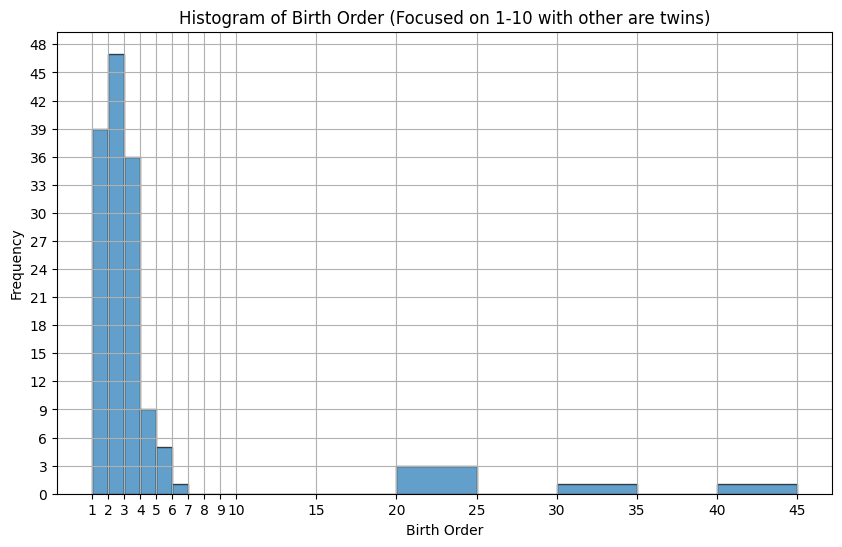

In [220]:
# نمایش هستوگرام چندمین فرزند
bins = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45]


plt.figure(figsize=(10, 6))
df["Birth Order"].hist(bins=bins, edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on 1-10 with other are twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(bins)
max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()


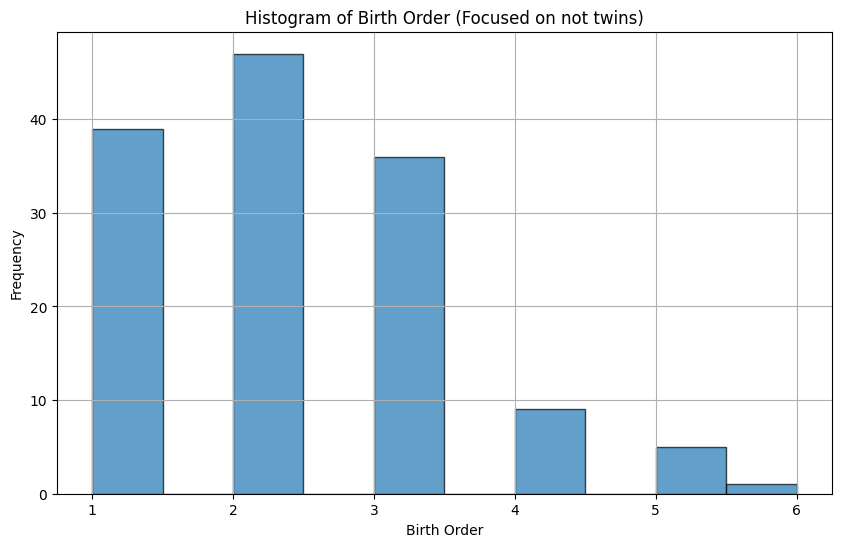

In [221]:
#هستوگرام بدون در نظر گرفتن چند قلو ها
plt.figure(figsize=(10, 6))
df["Birth Order"].where(df["Birth Order"]<10).hist(edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on not twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
# plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   142 non-null    float64
 1   Age                                      142 non-null    float64
 2   Birth Order                              142 non-null    Int64  
 3   Mother's Age at Pregnancy (Years)        142 non-null    float64
 4   Abortion History                         140 non-null    float64
 5   Type of Delivery                         99 non-null     float64
 6   Mother Underweight (BMI < 18.5)          142 non-null    float64
 7   Pressure                                 118 non-null    float64
 8   Blood Pressure (Week 24-30) - Systolic   68 non-null     float64
 9   Blood Pressure (Week 24-30) - Diastolic  68 non-null     float64
 10  Blood Pressure (Week 31-34) - Systolic   6

In [223]:
df["Head Circumference at Birth (cm)"].unique()

array([nan, '35', '34', ' NA', '32.5', '33', '32', '29', '36', '31',
       '34.5', '33.5', '30', '36.5', '30.5', '50'], dtype=object)

In [224]:
df["Head Circumference at Birth (cm)"] = pd.to_numeric(df["Head Circumference at Birth (cm)"], errors='coerce').astype('float64')

In [225]:
df["Head Circumference at Birth (cm)"].unique()

array([ nan, 35. , 34. , 32.5, 33. , 32. , 29. , 36. , 31. , 34.5, 33.5,
       30. , 36.5, 30.5, 50. ])

In [226]:
df["Weight at Birth (kg)"].unique()

array([nan, '3.28', '3', '3.34', ' NA', '3.25', '2.95', '3.05', '2.8',
       '3.29', '2.1', '2.9', '2.6', '2', '2.73', '3.3', '2.88', '2.31',
       '2.44', '2.53', '2.5', '1.89', '2.68', '2.45', '3.2', '2.47',
       '2.77', '2.05', '3.1', '2.51', '3.16', '2.78', '1', '2.25', '3.4',
       '2.33', '2.7', '3.02', '3.15', '2.2', '1.6', '2.85', '3.6',
       '2.645', '2.3', '2.75', '2.81', '1.9', '2.545', '1.7', '2.56'],
      dtype=object)

In [227]:
df["Weight at Birth (kg)"] = pd.to_numeric(df["Weight at Birth (kg)"], errors='coerce').astype('float64')

In [228]:
df["Weight at Birth (kg)"].unique()

array([  nan, 3.28 , 3.   , 3.34 , 3.25 , 2.95 , 3.05 , 2.8  , 3.29 ,
       2.1  , 2.9  , 2.6  , 2.   , 2.73 , 3.3  , 2.88 , 2.31 , 2.44 ,
       2.53 , 2.5  , 1.89 , 2.68 , 2.45 , 3.2  , 2.47 , 2.77 , 2.05 ,
       3.1  , 2.51 , 3.16 , 2.78 , 1.   , 2.25 , 3.4  , 2.33 , 2.7  ,
       3.02 , 3.15 , 2.2  , 1.6  , 2.85 , 3.6  , 2.645, 2.3  , 2.75 ,
       2.81 , 1.9  , 2.545, 1.7  , 2.56 ])

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   142 non-null    float64
 1   Age                                      142 non-null    float64
 2   Birth Order                              142 non-null    Int64  
 3   Mother's Age at Pregnancy (Years)        142 non-null    float64
 4   Abortion History                         140 non-null    float64
 5   Type of Delivery                         99 non-null     float64
 6   Mother Underweight (BMI < 18.5)          142 non-null    float64
 7   Pressure                                 118 non-null    float64
 8   Blood Pressure (Week 24-30) - Systolic   68 non-null     float64
 9   Blood Pressure (Week 24-30) - Diastolic  68 non-null     float64
 10  Blood Pressure (Week 31-34) - Systolic   6

In [230]:
df["Gender"].unique()

array([ 2.,  1., nan])

In [231]:
df["Gender"] = pd.to_numeric(df["Gender"], errors='coerce').astype('Int64')
df["Gender"].unique()

<IntegerArray>
[2, 1, <NA>]
Length: 3, dtype: Int64

In [232]:
df["Pressure"].unique()

array([ 2.,  1., nan,  3.])

In [233]:
df["Pressure"] = pd.to_numeric(df["Pressure"], errors='coerce').astype('Int64')
df["Pressure"].unique()

<IntegerArray>
[2, 1, <NA>, 3]
Length: 4, dtype: Int64

In [234]:
df["Malnutrition Type"].unique()

array(['4', '6', '4,6', '2,4', '6,3', '1', '2', '2,4,6', '4,5', '2,3,6',
       '1,3,6', '1,4', '5', '2و4و6', '1,3', nan, '4 , 5', '4 , 2',
       '2 , 4', '2 , 4 , 6', ' 2 , 4', '2 و 4', '1,6', '2,6,4', '3,5',
       '4 , 6', '2 , 3 , 6'], dtype=object)

In [235]:
df["Malnutrition Type"] = df["Malnutrition Type"].apply(lambda x: [s.strip() for s in re.split('[,و]', str(x))] if pd.notna(x) else [])

In [236]:
df.head()

,Gender,Age,Birth Order,Mother's Age at Pregnancy (Years),Abortion History,Type of Delivery,Mother Underweight (BMI < 18.5),Pressure,Blood Pressure (Week 24-30) - Systolic,Blood Pressure (Week 24-30) - Diastolic,Blood Pressure (Week 31-34) - Systolic,Blood Pressure (Week 31-34) - Diastolic,Blood Pressure (Week 36-37) - Systolic,Blood Pressure (Week 36-37) - Diastolic,Pregnancy Weeks,Gestational Diabetes,Diabetes (Week 6-10),Diabetes (Week 24-30),Developmental Issues (2 Months),Developmental Issues (9 Months),Developmental Issues (18 Months),Breast Milk Sufficiency (3-5 Days),Head Circumference at Birth (cm),Head Circumference (14-15 Days),Head Circumference at 1 Year (cm),Head Circumference Check (14-15 Days),Head Circumference Check (1 Year),Height at Birth (cm),Height at 6 Months (cm),Height at 12 Months (cm),Height at 18 Months (cm),Height at 2 Years (cm),Height at 3 Years (cm),Height at 4 Years (cm),Weight at Birth (kg),Weight at 6 Months (kg),Weight at 12 Months (kg),Weight at 18 Months (kg),Weight at 2 Years (kg),Weight at 3 Years (kg),Weight at 4 Years (kg),Hypothyroidism (3-5 Days),Malnutrition Type
0,2,52.0,2,33.0,NaN,3.0,2.0,2,100.0,60.0,110.0,55.0,NaN,NaN,39.0,2.0,NaN,NaN,2.0,3.0,2.0,2.0,NaN,NaN,45.0,NaN,1.0,NaN,66.0,70.0,76.0,NaN,88.0,97.0,NaN,6.30,7.60,8.5,NaN,10.65,13.0,3.0,[4]
1,2,37.0,1,35.0,2.0,2.0,2.0,2,100.0,60.0,110.0,60.0,125.0,70.0,39.0,2.0,NaN,NaN,2.0,2.0,2.0,3.0,35.0,36.5,45.3,1.0,1.0,50.0,62.5,72.5,77.0,83.0,94.0,NaN,3.28,6.10,8.35,9.5,10.35,12.00,NaN,2.0,[6]
2,2,29.0,2,39.0,1.0,3.0,2.0,1,NaN,NaN,NaN,NaN,NaN,NaN,37.0,2.0,NaN,NaN,3.0,2.0,2.0,3.0,35.0,34.5,45.0,1.0,1.0,50.0,64.5,71.0,78.0,84.0,NaN,NaN,3.28,6.55,7.78,9.0,9.50,NaN,NaN,3.0,"[4, 6]"
3,2,70.0,1,19.0,NaN,3.0,1.0,2,120.0,80.0,NaN,NaN,100.0,60.0,NaN,NaN,NaN,NaN,4.0,1.0,4.0,2.0,NaN,34.0,43.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,"[2, 4]"
4,2,28.0,1,39.0,1.0,3.0,2.0,2,100.0,60.0,100.0,60.0,110.0,74.0,39.0,1.0,92.0,97.0,2.0,2.0,2.0,2.0,NaN,35.0,44.5,4.0,1.0,50.0,66.0,74.0,78.0,87.0,NaN,NaN,3.00,6.00,7.70,8.9,9.50,NaN,NaN,3.0,"[6, 3]"


In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 43 columns):
 #   Column                                   Non-Null Count    Dtype  
---  ------                                   --------------    -----  
 0   Gender                                   142 non-null      Int64  
 1   Age                                      142 non-null      float64
 2   Birth Order                              142 non-null      Int64  
 3   Mother's Age at Pregnancy (Years)        142 non-null      float64
 4   Abortion History                         140 non-null      float64
 5   Type of Delivery                         99 non-null       float64
 6   Mother Underweight (BMI < 18.5)          142 non-null      float64
 7   Pressure                                 118 non-null      Int64  
 8   Blood Pressure (Week 24-30) - Systolic   68 non-null       float64
 9   Blood Pressure (Week 24-30) - Diastolic  68 non-null       float64
 10  Blood Pressure (We

### Data Nan Values

In [240]:
print(df.isna().sum())

Gender                                     1048433
Age                                        1048433
Birth Order                                1048433
Mother's Age at Pregnancy (Years)          1048433
Abortion History                           1048435
Type of Delivery                           1048476
Mother Underweight (BMI < 18.5)            1048433
Pressure                                   1048457
Blood Pressure (Week 24-30) - Systolic     1048507
Blood Pressure (Week 24-30) - Diastolic    1048507
Blood Pressure (Week 31-34) - Systolic     1048514
Blood Pressure (Week 31-34) - Diastolic    1048514
Blood Pressure (Week 36-37) - Systolic     1048520
Blood Pressure (Week 36-37) - Diastolic    1048521
Pregnancy Weeks                            1048478
Gestational Diabetes                       1048434
Diabetes (Week 6-10)                       1048548
Diabetes (Week 24-30)                      1048551
Developmental Issues (2 Months)            1048433
Developmental Issues (9 Months)

In [243]:
df.shape

(1048575, 43)